In [1]:
# ─── CELL 1: mount & navigate ───────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir("/content/drive/MyDrive/Multi-Agent-RAG-System-for-Enterprise-Document-Intelligence")
sys.path.insert(0, '.')
print("Working dir:", os.getcwd())

Mounted at /content/drive
Working dir: /content/drive/MyDrive/Multi-Agent-RAG-System-for-Enterprise-Document-Intelligence


In [2]:
# ─── CELL 2: install ────────────────────────────────────────────────────
!pip install langchain langchain-community langchain-core \
             langchain-groq langgraph groq \
             faiss-cpu sentence-transformers \
             datasets pandas numpy matplotlib -q
print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
Done.


In [4]:
# ─── CELL 3: setup LLM ───────────────────────────────────────────────────
from google.colab import userdata
from langchain_groq import ChatGroq

GROQ_API_KEY = userdata.get('GROQ_API')

llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model="llama-3.1-8b-instant",
    temperature=0.1,
    max_tokens=512
)
print("LLM ready.")

LLM ready.


In [5]:
# ─── CELL 4: load data ───────────────────────────────────────────────────
import pandas as pd

df_qa = pd.read_csv("data/processed/qa_pairs.csv")
print(f"QA pairs: {len(df_qa)}")
print(df_qa.head(3))

QA pairs: 491
   id                                           question  \
0   0                                        what is rba   
1   1                       was ronald reagan a democrat   
2   2  how long do you need for sydney and surroundin...   

                                              answer  
0  Results-Based Accountability is a disciplined ...  
1                                                Yes  
2                                      20-25 minutes  


In [8]:
# ─── CELL 5: evaluation functions ───────────────────────────────────────
def is_correct(ground_truth: str, agent_answer: str) -> bool:
    """
    Relaxed keyword match — 70% of significant words must appear.
    More forgiving than exact match since LLM paraphrases answers.
    """
    gt     = str(ground_truth).lower().strip()
    answer = str(agent_answer).lower().strip()

    # exact match
    if gt in answer:
        return True

    # partial match
    words   = [w for w in gt.split() if len(w) > 3]
    if not words:
        return gt in answer
    matches = sum(1 for w in words if w in answer)
    return matches / len(words) >= 0.7


def is_agent_successful(answer: str) -> bool:
    """Check if agent reached a final answer vs failed."""
    fail_phrases = [
        "stopped due to iteration",
        "error:",
        "i don't know",
        "cannot be determined",
        "no information"
    ]
    answer_lower = answer.lower()
    return not any(p in answer_lower for p in fail_phrases)

In [9]:
# ─── CELL 6: run evaluation on 30 samples ───────────────────────────────
# 30 samples — enough for meaningful results, manageable API usage
import time, json
from src.graph import run_pipeline

os.makedirs("results", exist_ok=True)

eval_qa  = df_qa.head(30)
results  = []

print(f"Evaluating multi-agent pipeline on {len(eval_qa)} QA pairs...\n")

for i, row in eval_qa.iterrows():
    question = row['question']
    gt       = str(row['answer'])

    t0     = time.perf_counter()
    result = run_pipeline(question, llm)
    elapsed = time.perf_counter() - t0

    answer  = result['final_answer']
    correct = is_correct(gt, answer)
    success = is_agent_successful(answer)

    results.append({
        'id':            row['id'],
        'question':      question,
        'ground_truth':  gt,
        'final_answer':  answer,
        'analyst_facts': result['analyst_facts'],
        'correct':       correct,
        'success':       success,
        'time_sec':      round(elapsed, 3)
    })

    status = "✓" if correct else "✗"
    print(f"[{len(results):02d}/30] {status} ({elapsed:.1f}s) {question[:55]}")

    # checkpoint every 10
    if len(results) % 10 == 0:
        pd.DataFrame(results).to_csv(
            "results/eval_checkpoint.csv", index=False)
        print(f"  checkpoint saved at {len(results)}/30")

    time.sleep(1)  # respect rate limits

df_results = pd.DataFrame(results)
df_results.to_csv("results/evaluation_results.csv", index=False)
print("\nEvaluation complete.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Retrieval tool: index built with 4089 vectors
Evaluating multi-agent pipeline on 30 QA pairs...


[RETRIEVER] Searching documents...
[RETRIEVER] Found 968 chars of content

[ANALYST] Extracting key facts...
[ANALYST] Extracted facts: • RBA stands for Risk-Based Authentication.
• RBA is a method of applying varying levels of stringen...

[SYNTHESISER] Generating final answer...
[SYNTHESISER] Answer: RBA stands for Risk-Based Authentication, a method of applying varying levels of stringency to authe...
[01/30] ✗ (1.0s) what is rba

[RETRIEVER] Searching documents...
[RETRIEVER] Found 1422 chars of content

[ANALYST] Extracting key facts...
[ANALYST] Extracted facts: • Ronald Reagan was a member of the Democratic Party in his younger years.
• He switched parties to ...

[SYNTHESISER] Generating final answer...
[SYNTHESISER] Answer: Ronald Reagan was a member of the Democratic Party in his younger years, but he switched parties to ...
[02/30] ✗ (0.7s) was ronald reagan a democrat

[RETRIEV

In [10]:
# ─── CELL 7: print summary ───────────────────────────────────────────────
accuracy     = df_results['correct'].mean()
success_rate = df_results['success'].mean()
avg_time     = df_results['time_sec'].mean()

summary = {
    'n_samples':        len(df_results),
    'accuracy':         round(accuracy,     3),
    'success_rate':     round(success_rate, 3),
    'avg_time_sec':     round(avg_time,     3),
    'total_time_sec':   round(df_results['time_sec'].sum(), 1)
}

with open("results/eval_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("="*50)
print("MULTI-AGENT PIPELINE EVALUATION")
print("="*50)
print(f"Samples evaluated:        {summary['n_samples']}")
print(f"Accuracy (keyword match): {accuracy:.1%}")
print(f"Success rate:             {success_rate:.1%}")
print(f"Avg time per query:       {avg_time:.2f}s")
print(f"Total evaluation time:    {summary['total_time_sec']}s")

MULTI-AGENT PIPELINE EVALUATION
Samples evaluated:        30
Accuracy (keyword match): 40.0%
Success rate:             100.0%
Avg time per query:       7.80s
Total evaluation time:    234.1s


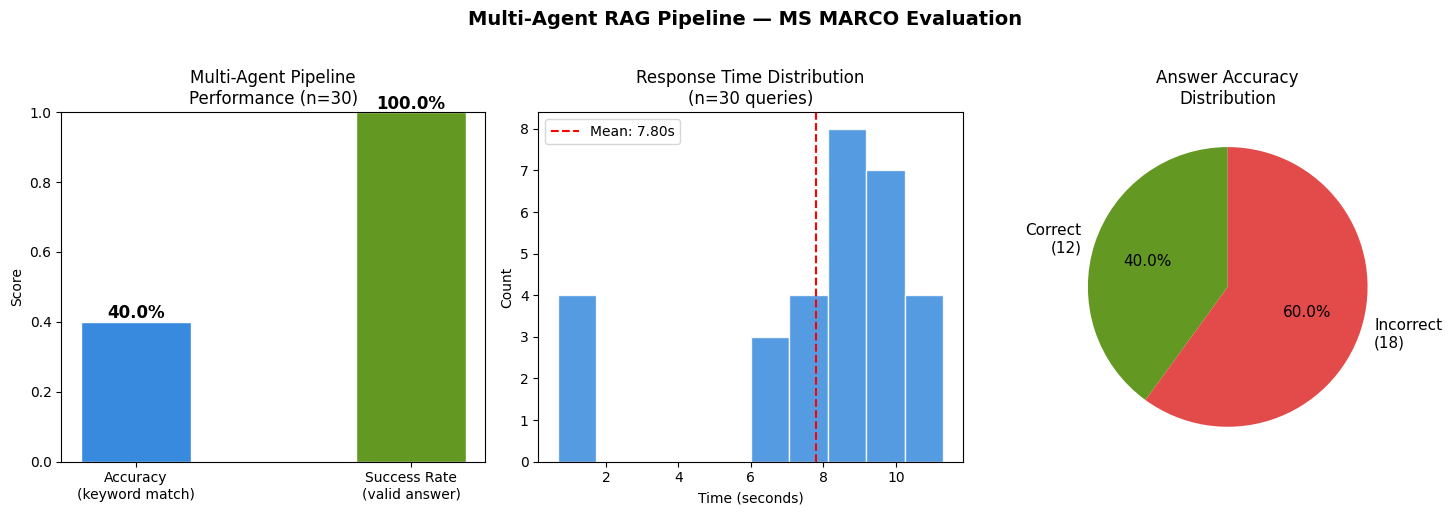

Plot saved.


In [11]:
# ─── CELL 8: generate plots ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

os.makedirs("results/figures", exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# plot 1 — accuracy and success rate
metrics = ['Accuracy\n(keyword match)', 'Success Rate\n(valid answer)']
values  = [summary['accuracy'], summary['success_rate']]
colors  = ['#378ADD', '#639922']
bars    = axes[0].bar(metrics, values, color=colors,
                      width=0.4, edgecolor='white')
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Multi-Agent Pipeline\nPerformance (n=30)", fontsize=12)
axes[0].set_ylabel("Score")
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + 0.01, f"{v:.1%}",
                 ha='center', fontsize=12, fontweight='bold')

# plot 2 — response time distribution
axes[1].hist(df_results['time_sec'], bins=10,
             color='#378ADD', edgecolor='white', alpha=0.85)
axes[1].axvline(avg_time, color='red', linestyle='--',
                linewidth=1.5, label=f"Mean: {avg_time:.2f}s")
axes[1].set_title("Response Time Distribution\n(n=30 queries)", fontsize=12)
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Count")
axes[1].legend()

# plot 3 — correct vs incorrect pie
correct   = df_results['correct'].sum()
incorrect = len(df_results) - correct
axes[2].pie(
    [correct, incorrect],
    labels=[f'Correct\n({correct})', f'Incorrect\n({incorrect})'],
    colors=['#639922', '#E24B4A'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11}
)
axes[2].set_title("Answer Accuracy\nDistribution", fontsize=12)

plt.suptitle(
    "Multi-Agent RAG Pipeline — MS MARCO Evaluation",
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig("results/figures/evaluation_results.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

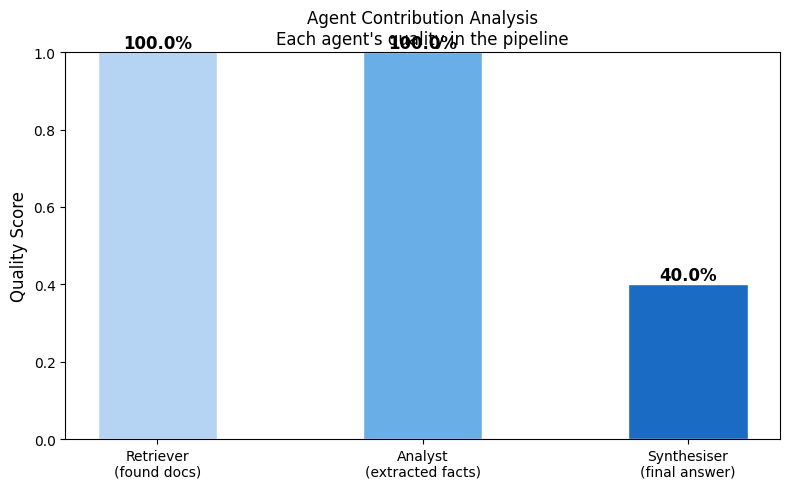

Agent contribution plot saved.


In [12]:
# ─── CELL 9: agent contribution analysis ────────────────────────────────
# shows value of each agent in the pipeline
fig, ax = plt.subplots(figsize=(8, 5))

# measure retriever quality — did it find relevant docs?
retriever_quality = df_results['final_answer'].apply(
    lambda x: 0 if 'cannot be determined' in x.lower() else 1
).mean()

# measure analyst contribution — did facts help?
analyst_quality = df_results['analyst_facts'].apply(
    lambda x: 0 if len(str(x)) < 50 else 1
).mean()

# overall pipeline accuracy
pipeline_accuracy = accuracy

agents   = ['Retriever\n(found docs)', 'Analyst\n(extracted facts)',
            'Synthesiser\n(final answer)']
scores   = [retriever_quality, analyst_quality, pipeline_accuracy]
colors   = ['#B5D4F4', '#6AAEE8', '#1A6BC4']

bars = ax.bar(agents, scores, color=colors,
              width=0.45, edgecolor='white')
ax.set_ylim(0, 1.0)
ax.set_ylabel("Quality Score", fontsize=12)
ax.set_title("Agent Contribution Analysis\nEach agent's quality in the pipeline",
             fontsize=12)
for bar, s in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            s + 0.01, f"{s:.1%}",
            ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("results/figures/agent_contribution.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Agent contribution plot saved.")

In [13]:
# ─── CELL 10: print sample outputs for README ────────────────────────────
print("=== SAMPLE PIPELINE OUTPUTS ===\n")
for _, row in df_results[df_results['correct']==True].head(3).iterrows():
    print(f"Q:  {row['question']}")
    print(f"GT: {row['ground_truth'][:150]}")
    print(f"A:  {row['final_answer'][:150]}")
    print("---")

=== SAMPLE PIPELINE OUTPUTS ===

Q:  how long do you need for sydney and surrounding areas
GT: 20-25 minutes
A:  Based on the provided context, it is recommended to spend at least a week to see many of the sights of Sydney and its surrounding areas, which cover a
---
Q:  price to install tile in shower
GT: $11 to $22 per square foot
A:  The average cost to install tile in a shower is $25 per square foot, with a total installation cost of around $2,000 for a medium-sized shower. Howeve
---
Q:  best tragedies of ancient greece
GT: Sophocles, Aeschylus and Euripides
A:  The best tragedies of ancient Greece are attributed to the three great tragedians: Aeschylus, Sophocles, and Euripides. These playwrights were famous 
---


In [1]:
!git config --global user.email "chaitanyamhetre97@email.com"
!git config --global user.name "chaitanyamhetre"

!git add .
!git commit -m "Evaluation framework, results, plots"
!git push
print("Pushed.")

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
Pushed.
